In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py
from scipy import stats

ModuleNotFoundError: No module named 'numpy'

In [3]:
snapnum = 40

In [3]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [4]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [5]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType", "SubhaloVmax", "SubhaloVmaxRad"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

12


<class 'dict'>


In [6]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [7]:
group_sfrs = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [8]:
vmax = subhalos["SubhaloVmax"]
rmax = subhalos["SubhaloVmaxRad"]

In [9]:
cent_vmax1 = subhalos["SubhaloVmax"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_vmax = np.zeros(len(mvir))
cent_vmax[halos["GroupFirstSub"]>-1] = cent_vmax1

In [10]:
cent_rmax1 = subhalos["SubhaloVmaxRad"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_rmax = np.zeros(len(mvir))
cent_rmax[halos["GroupFirstSub"]>-1] = cent_rmax1

In [11]:
cent_cprox = cent_vmax/cent_rmax

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


In [12]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [13]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [14]:
sat_mass = subhalos["SubhaloMass"][~cent_mask_all]*1e10

In [15]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [16]:
sum_mass1 =  np.add.reduceat(sat_mass, indices)
sum_sat_mass = np.zeros(len(halos["GroupFirstSub"]))
sum_sat_mass[unique_ids] = sum_mass1
sum_sat_mass = np.log10(sum_sat_mass)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in true_divide
  if __name__ == '__main__':


Text(0, 0.5, 'Msat')

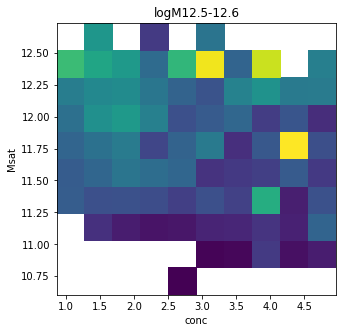

In [166]:
from matplotlib.colors import LogNorm
logM = 12.5
dlogM = 0.1
mask = (cent_cprox > -5) & (sum_sat_mass > -5) & (group_sfrs>-5) & (mvir > logM) &  (mvir < logM+dlogM) & (cent_cprox < 5)
hist, xedges, yedges = np.histogram2d(cent_cprox[mask], sum_sat_mass[mask],bins=10)
hist2, xedges2, yedges2 = np.histogram2d(cent_cprox[mask], sum_sat_mass[mask], weights=10**group_sfrs[mask],bins=10)
#hist3, xedges3, yedges3, im = plt.hist2d(np.log10(cent_cprox[mask]), sum_sat_mass[mask], weights=10**group_sfrs[mask],bins=100 , cmap='viridis', norm=LogNorm())

hist_av = hist2/hist
#plt.imshow(hist_av)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot( title='pcolormesh: actual edges',
        aspect='equal')
X, Y = np.meshgrid(xedges, yedges)
ax.pcolormesh(X, Y, hist_av.T)
#plt.colorbar()
plt.title(f"logM{logM}-{logM+dlogM}")
plt.xlabel("conc")
plt.ylabel("Msat")

In [91]:
10**xedges[6]

1.0382603305939064

Text(0.5, 1.0, 'logM12.5-12.6')

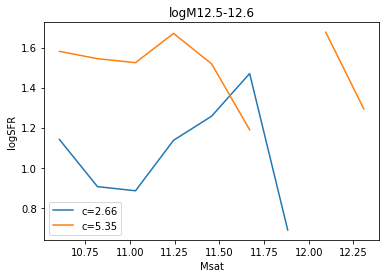

In [147]:
#mask = (xedges > 10) & (xedges < 20)

plt.plot(yedges[:-1], np.log10(hist_av[:,2]), label=f"c={np.round(xedges[2],2)}")
plt.plot(yedges[:-1], np.log10(hist_av[:,5]), label=f"c={np.round(xedges[5],2)}")
plt.legend()
plt.xlabel("Msat")
plt.ylabel("logSFR")
plt.title(f"logM{logM}-{logM+dlogM}")

Text(0.5, 1.0, 'logM12.5-12.6')

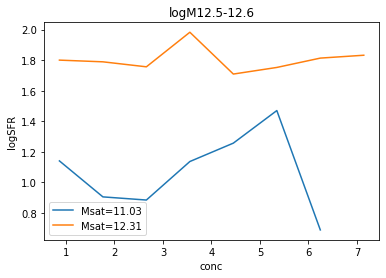

In [152]:
#mask = (xedges > 10) & (xedges < 20)

plt.plot(xedges[:-1], np.log10(hist_av[:,2]), label=f"Msat={np.round(yedges[2],2)}")
plt.plot(xedges[:-1], np.log10(hist_av[:,8]), label=f"Msat={np.round(yedges[8],2)}")
plt.legend()
plt.xlabel("conc")
plt.ylabel("logSFR")
plt.title(f"logM{logM}-{logM+dlogM}")